# 01 — Dataset Analysis

**PredictAI — Predictive Maintenance & Machine Health Platform**

Dataset: **AI4I 2020 Predictive Maintenance Dataset** (Matzka, 2020 — UCI ML Repository).
10,000 rows of milling-machine process data with a binary machine-failure label
and five per-mode failure labels.

### What this notebook has to establish before any model is trained

1. What each column physically means, and its unit.
2. Which columns are **features** and which are **label leakage**.
3. How severe the class imbalance is, and what that implies for the metric choice.
4. Whether the data actually supports the sequential/RUL modelling planned for
   notebooks 06–07 — this is a structural question and the answer changes the roadmap.
5. A **frozen train/val/test split** that every subsequent notebook reuses.

### Deliverables

* `data/processed/ai4i_clean.parquet` — cleaned frame with engineered features
* `data/processed/split_indices.json` — the frozen split
* figures in `reports/figures/`

In [1]:
import sys
from pathlib import Path

# Make the `ml` package importable when running from notebooks/
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ml import data as D
from ml.paths import CLEAN_PARQUET, SPLIT_JSON
from ml.viz import set_style, save_fig, OK, BAD, NEUTRAL, WARN

set_style()
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)

print(f"pandas {pd.__version__} | numpy {np.__version__}")

pandas 2.3.3 | numpy 2.0.2


## 1. Load and first look

In [2]:
df = D.load_raw()
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

Shape: 10,000 rows x 14 columns


,udi,product_id,type,air_temp_k,process_temp_k,rotational_speed_rpm,torque_nm,tool_wear_min,machine_failure,twf,hdf,pwf,osf,rnf
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## 2. Schema — meaning, unit, and role

The **role** column is the important one. Five of these columns cannot be used as
model inputs, and the reason is explained in section 5.

In [3]:
schema = pd.DataFrame(
    [
        ("udi", "—", "identifier", "Row index, 1–10000"),
        ("product_id", "—", "identifier", "Quality letter + serial number"),
        ("type", "L/M/H", "feature (categorical)", "Product quality variant"),
        ("air_temp_k", "K", "feature (sensor)", "Ambient air temperature"),
        ("process_temp_k", "K", "feature (sensor)", "Process temperature at the tool"),
        ("rotational_speed_rpm", "rpm", "feature (sensor)", "Spindle speed"),
        ("torque_nm", "Nm", "feature (sensor)", "Applied torque"),
        ("tool_wear_min", "min", "feature (sensor)", "Cumulative tool usage"),
        ("machine_failure", "0/1", "TARGET", "Machine failed at this observation"),
        ("twf", "0/1", "LEAKAGE", "Tool wear failure mode"),
        ("hdf", "0/1", "LEAKAGE", "Heat dissipation failure mode"),
        ("pwf", "0/1", "LEAKAGE", "Power failure mode"),
        ("osf", "0/1", "LEAKAGE", "Overstrain failure mode"),
        ("rnf", "0/1", "LEAKAGE", "Random failure mode"),
    ],
    columns=["column", "unit", "role", "meaning"],
)
schema

,column,unit,role,meaning
0,udi,—,identifier,"Row index, 1–10000"
1,product_id,—,identifier,Quality letter + serial number
2,type,L/M/H,feature (categorical),Product quality variant
3,air_temp_k,K,feature (sensor),Ambient air temperature
4,process_temp_k,K,feature (sensor),Process temperature at the tool
5,rotational_speed_rpm,rpm,feature (sensor),Spindle speed
6,torque_nm,Nm,feature (sensor),Applied torque
7,tool_wear_min,min,feature (sensor),Cumulative tool usage
8,machine_failure,0/1,TARGET,Machine failed at this observation
9,twf,0/1,LEAKAGE,Tool wear failure mode


## 3. Data quality

Checking the things that silently break a pipeline later: missing values, duplicate
rows, duplicate identifiers, and dtype surprises.

In [4]:
quality = pd.DataFrame(
    {
        "dtype": df.dtypes.astype(str),
        "missing": df.isna().sum(),
        "missing_%": (df.isna().mean() * 100).round(2),
        "unique": df.nunique(),
    }
)
print(quality.to_string())

print(f"\nFully duplicated rows            : {df.duplicated().sum()}")
print(f"Duplicated udi values            : {df['udi'].duplicated().sum()}")
print(f"Duplicated product_id values     : {df['product_id'].duplicated().sum()}")

# product_id encodes the quality letter -- verify it agrees with `type`
mismatch = (df["product_id"].str[0] != df["type"]).sum()
print(f"product_id prefix != type        : {mismatch}")

                        dtype  missing  missing_%  unique
udi                     int64        0        0.0   10000
product_id             object        0        0.0   10000
type                   object        0        0.0       3
air_temp_k            float64        0        0.0      93
process_temp_k        float64        0        0.0      82
rotational_speed_rpm    int64        0        0.0     941
torque_nm             float64        0        0.0     577
tool_wear_min           int64        0        0.0     246
machine_failure         int64        0        0.0       2
twf                     int64        0        0.0       2
hdf                     int64        0        0.0       2
pwf                     int64        0        0.0       2
osf                     int64        0        0.0       2
rnf                     int64        0        0.0       2

Fully duplicated rows            : 0
Duplicated udi values            : 0
Duplicated product_id values     : 0
product_id prefix 

No missing values, no duplicates, and `product_id` is internally consistent with
`type`. This dataset is synthetic, generated to mimic a real milling machine, so it
is clean by construction — a real sensor feed will not be, and the ingestion layer
in the FastAPI service will still need null handling and range validation.

## 4. The target: how rare is failure?

In [5]:
counts = df[D.TARGET].value_counts().sort_index()
rate = df[D.TARGET].mean()

print(f"No failure : {counts[0]:>6,}  ({(1 - rate) * 100:.2f}%)")
print(f"Failure    : {counts[1]:>6,}  ({rate * 100:.2f}%)")
print(f"Imbalance ratio: {counts[0] / counts[1]:.1f} : 1")
print(f"\nA model that always predicts 'no failure' scores {(1 - rate) * 100:.2f}% accuracy")
print("and is completely useless. Accuracy is not a usable metric on this problem.")

No failure :  9,661  (96.61%)
Failure    :    339  (3.39%)
Imbalance ratio: 28.5 : 1

A model that always predicts 'no failure' scores 96.61% accuracy
and is completely useless. Accuracy is not a usable metric on this problem.


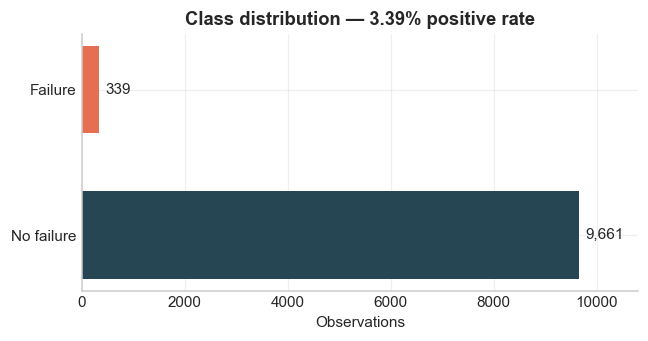

In [6]:
fig, ax = plt.subplots(figsize=(6, 3.2))
bars = ax.barh(["No failure", "Failure"], counts.values, color=[NEUTRAL, BAD], height=0.6)
for b, v in zip(bars, counts.values):
    ax.text(b.get_width() + 120, b.get_y() + b.get_height() / 2, f"{v:,}", va="center")
ax.set_xlim(0, 10800)
ax.set_xlabel("Observations")
ax.set_title("Class distribution — 3.39% positive rate")
save_fig("01_class_balance")
plt.show()

**Consequence for the rest of the project.** With 339 positives in 10,000 rows:

* The headline metric is **PR-AUC** (average precision), not ROC-AUC. ROC-AUC is
  inflated by the huge true-negative pool and will look impressive for a model that
  is not useful.
* **Recall** is the operational metric. A missed failure is unplanned downtime; a
  false alarm is a technician walking to a machine for nothing.
* The 0.5 decision threshold is arbitrary. Threshold selection is a separate,
  explicit step (notebook 03 onwards).

## 5. Failure modes — and why they are leakage

`machine_failure` is not an independent label. It is defined as the logical OR of
the five mode flags. Feeding `twf`/`hdf`/`pwf`/`osf` into a classifier gives a model
that scores ~1.00 in the notebook and predicts nothing useful in production, because
those flags are only known **at the same instant the failure is recorded** — a
machine in the field does not transmit "HDF = 1" ahead of time.

In [7]:
modes = df[D.FAILURE_MODES].sum()
mode_tbl = pd.DataFrame(
    {
        "count": modes,
        "% of all rows": (modes / len(df) * 100).round(2),
        "% of failures": (modes / df[D.TARGET].sum() * 100).round(1),
        "name": [D.FAILURE_MODE_NAMES[m] for m in D.FAILURE_MODES],
    }
)
print(mode_tbl.to_string())
print(f"\nSum of mode flags : {modes.sum()}")
print(f"machine_failure   : {df[D.TARGET].sum()}")
print("Sum exceeds the target because some rows trip more than one mode at once.")

     count  % of all rows  % of failures                      name
twf     46           0.46           13.6         Tool Wear Failure
hdf    115           1.15           33.9  Heat Dissipation Failure
pwf     95           0.95           28.0             Power Failure
osf     98           0.98           28.9        Overstrain Failure
rnf     19           0.19            5.6            Random Failure

Sum of mode flags : 373
machine_failure   : 339
Sum exceeds the target because some rows trip more than one mode at once.


In [8]:
# Is machine_failure exactly the OR of the mode flags? Test both directions.
process_modes = ["twf", "hdf", "pwf", "osf"]  # deterministic, physics-driven
any_process = df[process_modes].max(axis=1)

a = ((df[D.TARGET] == 1) & (any_process == 0)).sum()
b = ((df[D.TARGET] == 0) & (any_process == 1)).sum()
c = ((df["rnf"] == 1) & (df[D.TARGET] == 0)).sum()
d = ((df["rnf"] == 1) & (df[D.TARGET] == 1)).sum()

print(f"failure=1 but no process mode flagged : {a}")
print(f"process mode flagged but failure=0    : {b}")
print(f"rnf=1 and failure=0                   : {c}")
print(f"rnf=1 and failure=1                   : {d}   (total rnf = {df['rnf'].sum()})")

failure=1 but no process mode flagged : 9
process mode flagged but failure=0    : 0
rnf=1 and failure=0                   : 18
rnf=1 and failure=1                   : 1   (total rnf = 19)


### Two label-consistency findings

**(a) The RNF column is disconnected from the target.** Of the 19 rows with
`rnf = 1`, 18 have `machine_failure = 0`. The generator flips RNF at random,
independently of the process, and those flips were never propagated into the target.
RNF is therefore both unlearnable (no relationship to any sensor, by construction)
and irrelevant (not part of the label). Dropped entirely.

**(b) Nine failures have no assigned mode.** Nine rows carry `machine_failure = 1`
while all four process modes and RNF are 0. The other direction never happens: every
flagged process mode does appear in the target.

In [9]:
unexplained = df[(df[D.TARGET] == 1) & (any_process == 0)]
print(unexplained[["udi", "type"] + D.SENSOR_COLS].to_string(index=False))

 udi type  air_temp_k  process_temp_k  rotational_speed_rpm  torque_nm  tool_wear_min
1438    H       298.8           309.9                  1439       45.2             40
2750    M       299.7           309.2                  1685       28.9            179
4045    M       301.9           310.9                  1419       47.7             20
4685    M       303.6           311.8                  1421       44.8            101
5537    M       302.3           311.8                  1363       54.0            119
5942    L       300.6           310.7                  1438       48.5             78
6479    L       300.5           309.8                  1663       29.1            145
8507    L       298.4           309.6                  1710       27.3            163
9016    L       297.2           308.1                  1431       49.7            210


These nine sit inside completely ordinary sensor ranges — no extreme torque, no heat
build-up, no worn tool. They are unexplainable from the inputs.

**This sets a hard ceiling on recall.** The four process modes are *deterministic
threshold rules* on the sensors (verified in notebook 02). A model that learned all
four rules perfectly would still miss these nine:

$$\text{max achievable recall} = \frac{339 - 9}{339} = 97.3\%$$

That number is worth carrying through the whole project. When notebook 04 reports
~85% recall, the gap to close is 12 points against a 97.3% ceiling — not 15 against
a 100% one. Reporting a model at "99% recall" on this dataset would be evidence of
leakage, not of a good model.

In [10]:
ceiling = (df[D.TARGET].sum() - a) / df[D.TARGET].sum()
print(f"Learnable positives : {df[D.TARGET].sum() - a} / {df[D.TARGET].sum()}")
print(f"Recall ceiling      : {ceiling:.1%}")

Learnable positives : 330 / 339
Recall ceiling      : 97.3%


## 6. Product quality variant

In [11]:
by_type = (
    df.groupby("type")
    .agg(n=("udi", "size"), failures=(D.TARGET, "sum"), failure_rate=(D.TARGET, "mean"))
    .reindex(["L", "M", "H"])
)
by_type["failure_rate_%"] = (by_type["failure_rate"] * 100).round(2)
by_type["share_of_data_%"] = (by_type["n"] / len(df) * 100).round(1)
print(by_type.drop(columns="failure_rate").to_string())

         n  failures  failure_rate_%  share_of_data_%
type                                                 
L     6000       235            3.92             60.0
M     2997        83            2.77             30.0
H     1003        21            2.09             10.0


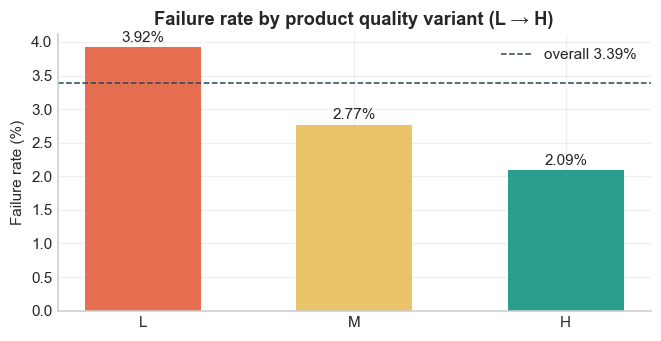

In [12]:
fig, ax = plt.subplots(figsize=(6, 3.2))
ax.bar(by_type.index, by_type["failure_rate_%"], color=[BAD, WARN, OK], width=0.55)
for i, v in enumerate(by_type["failure_rate_%"]):
    ax.text(i, v + 0.08, f"{v:.2f}%", ha="center")
ax.axhline(rate * 100, ls="--", c=NEUTRAL, lw=1, label=f"overall {rate * 100:.2f}%")
ax.set_ylabel("Failure rate (%)")
ax.set_title("Failure rate by product quality variant (L → H)")
ax.legend()
save_fig("01_failure_rate_by_type")
plt.show()

Failure rate falls monotonically from the low-quality to the high-quality variant.
The ordering is real information, so `type` is encoded as an **ordinal** (L=0, M=1,
H=2) as well as being available for one-hot encoding in the linear baseline.

## 7. Sensor ranges

In [13]:
stats = df[D.SENSOR_COLS].describe().T
stats["range"] = stats["max"] - stats["min"]
stats["cv"] = (stats["std"] / stats["mean"]).round(3)
print(stats[["mean", "std", "min", "25%", "50%", "75%", "max", "range", "cv"]].round(2).to_string())

                         mean     std     min     25%     50%     75%     max   range    cv
air_temp_k             300.00    2.00   295.3   298.3   300.1   301.5   304.5     9.2  0.01
process_temp_k         310.01    1.48   305.7   308.8   310.1   311.1   313.8     8.1  0.00
rotational_speed_rpm  1538.78  179.28  1168.0  1423.0  1503.0  1612.0  2886.0  1718.0  0.12
torque_nm               39.99    9.97     3.8    33.2    40.1    46.8    76.6    72.8  0.25
tool_wear_min          107.95   63.65     0.0    53.0   108.0   162.0   253.0   253.0  0.59


Note the scales: temperatures sit around 300 (Kelvin) with a spread of ~2, while
rotational speed spans ~1,300–2,900. Any distance- or gradient-based model
(logistic regression, autoencoder, LSTM) **must** have these scaled, or rotational
speed will dominate purely by magnitude. Tree models are invariant to this.

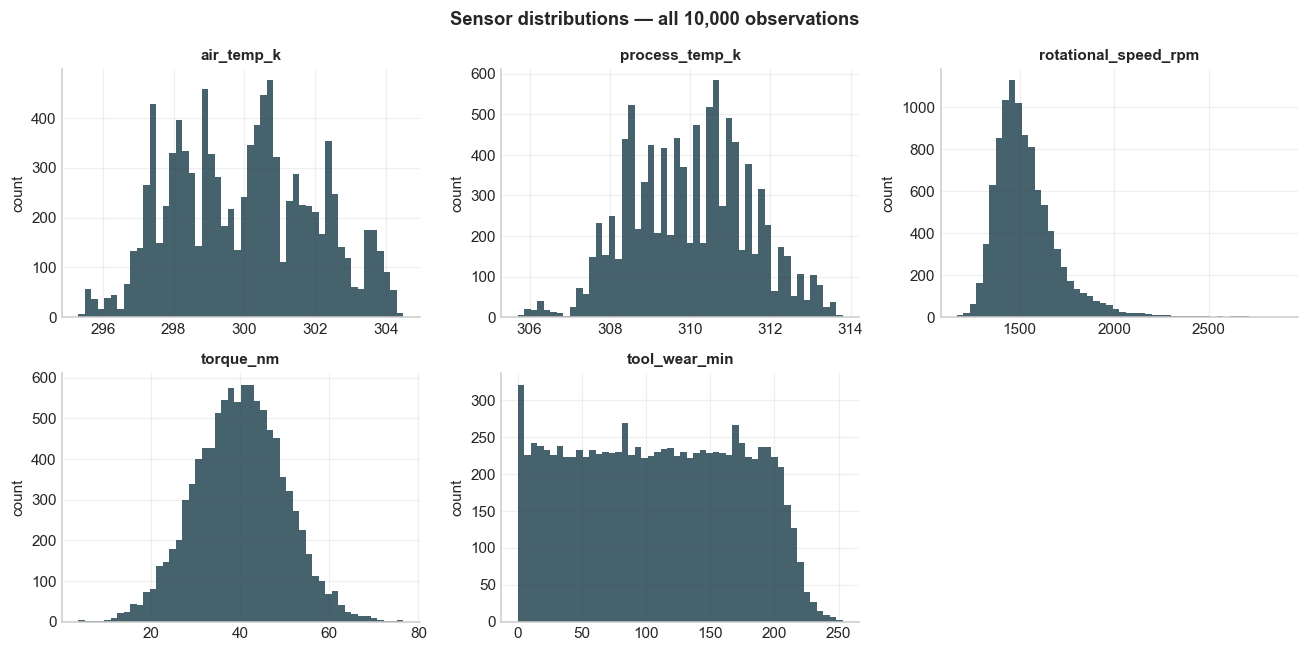

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for ax, col in zip(axes.ravel(), D.SENSOR_COLS):
    ax.hist(df[col], bins=50, color=NEUTRAL, alpha=0.85)
    ax.set_title(col, fontsize=10)
    ax.set_ylabel("count")
axes.ravel()[-1].axis("off")
fig.suptitle("Sensor distributions — all 10,000 observations", fontweight="bold")
save_fig("01_sensor_distributions")
plt.show()

Air and process temperature are bimodal (the generator uses a random walk with
drift), rotational speed is right-skewed, torque is close to normal, and tool wear
is near-uniform 0–253 min — consistent with tools being run to replacement and
reset. Tool wear being uniform rather than concentrated means the dataset covers
the whole tool life, which is what makes wear-driven failure learnable.

## 8. The structural question: is this actually time series?

The project plan (notebooks 06 and 07) calls for an **LSTM over sensor sequences**
and **remaining-useful-life regression**. Both require knowing *which machine* a
reading came from and *when* it was taken. Checking whether those exist:

In [15]:
print("Columns present:", list(df.columns))
print()
for candidate in ["machine_id", "unit", "timestamp", "time", "cycle", "date"]:
    print(f"  '{candidate}' present: {candidate in df.columns}")
print(f"\nUnique product_id values: {df['product_id'].nunique():,} across {len(df):,} rows")
print("-> product_id is a per-row serial number, not a machine identifier.")

Columns present: ['udi', 'product_id', 'type', 'air_temp_k', 'process_temp_k', 'rotational_speed_rpm', 'torque_nm', 'tool_wear_min', 'machine_failure', 'twf', 'hdf', 'pwf', 'osf', 'rnf']

  'machine_id' present: False
  'unit' present: False
  'timestamp' present: False
  'time' present: False
  'cycle' present: False
  'date' present: False

Unique product_id values: 10,000 across 10,000 rows
-> product_id is a per-row serial number, not a machine identifier.


### Finding — this changes the roadmap

AI4I 2020 has **no machine identifier and no timestamp**. Each row is an independent
snapshot of a process at one moment. There are no per-machine trajectories, so:

| Planned notebook | Feasible on AI4I? | Why |
|---|---|---|
| 01 dataset analysis | ✅ | — |
| 02 sensor analysis | ✅ | — |
| 03 baseline (logistic regression) | ✅ | tabular classification |
| 04 XGBoost | ✅ | tabular classification |
| 05 anomaly detection (Isolation Forest) | ✅ | point anomalies, no sequence needed |
| 06 autoencoder | ✅ | reconstructs a single reading |
| 07 **LSTM over sequences** | ❌ | no sequences exist to learn from |
| 07 **RUL regression** | ❌ | no time-to-failure is measurable |
| 09 SHAP / 10 error analysis | ✅ | — |

`tool_wear_min` is the *only* quantity with a time-like ordering, and it resets per
tool rather than tracking a machine. Building an "LSTM" by sorting rows on tool wear
and sliding a window over unrelated machines would produce a model that appears to
work in the notebook and is meaningless — an interviewer who knows this dataset will
spot it immediately.

**Decision:** AI4I carries notebooks 01–06 and 09–10 (classification + anomaly
detection). The sequential half of the project — LSTM and RUL — moves to
**NASA C-MAPSS**, which has `unit_number`, `time_in_cycles`, and run-to-failure
trajectories, i.e. the structure RUL is actually defined on. The two datasets feed
two panels of the same dashboard: *is this machine failing now* (AI4I) and *how long
until it fails* (C-MAPSS).

## 9. Engineered features

Built now so they can be validated against the documented failure physics in
notebook 02. Definitions live in `ml/data.py` so training and inference cannot drift
apart.

In [16]:
df = D.engineer_features(df)
print(df[D.ENGINEERED_COLS].describe().round(2).to_string())

       temp_diff_k   power_w  wear_torque  type_ordinal
count      10000.0  10000.00     10000.00      10000.00
mean          10.0   6279.74      4314.66          0.50
std            1.0   1067.42      2826.57          0.67
min            7.6   1148.44         0.00          0.00
25%            9.3   5561.18      1963.65          0.00
50%            9.8   6271.03      4012.95          0.00
75%           11.0   7003.00      6279.00          1.00
max           12.1  10469.92     16497.00          2.00


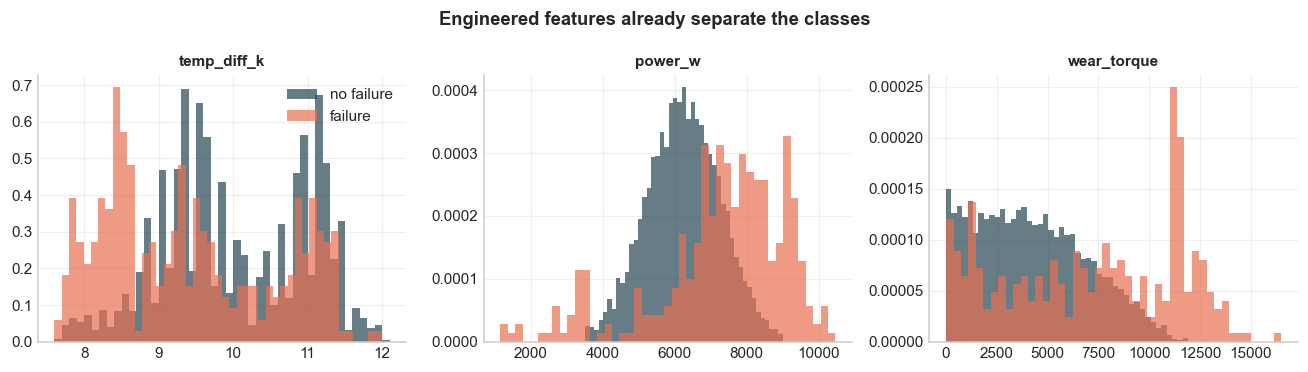

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))
for ax, col in zip(axes, ["temp_diff_k", "power_w", "wear_torque"]):
    ax.hist(df.loc[df[D.TARGET] == 0, col], bins=45, color=NEUTRAL, alpha=0.7, density=True, label="no failure")
    ax.hist(df.loc[df[D.TARGET] == 1, col], bins=45, color=BAD, alpha=0.7, density=True, label="failure")
    ax.set_title(col, fontsize=10)
axes[0].legend()
fig.suptitle("Engineered features already separate the classes", fontweight="bold")
save_fig("01_engineered_features")
plt.show()

All three show visibly different conditional distributions — `power_w` is bimodal
under failure (both starvation and overload cause it), and `wear_torque` shifts
hard right. That is the signal notebook 02 quantifies.

## 10. Freeze the split

Stratified 60/20/20, seed 42, keyed on `udi` and written to disk. Every later
notebook loads *this* file. Without it, the model comparison in notebook 08 would be
comparing models trained on different rows.

In [18]:
split = D.make_split(df)
train, val, test = D.apply_split(df, split)

split_tbl = pd.DataFrame(
    {
        "rows": [len(train), len(val), len(test)],
        "failures": [int(x[D.TARGET].sum()) for x in (train, val, test)],
        "failure_rate_%": [round(x[D.TARGET].mean() * 100, 2) for x in (train, val, test)],
    },
    index=["train", "val", "test"],
)
print(split_tbl.to_string())
print(f"\nSeed: {split['seed']}   ->  {SPLIT_JSON}")

       rows  failures  failure_rate_%
train  6000       203            3.38
val    2000        68            3.40
test   2000        68            3.40

Seed: 42   ->  /Users/prassanna/Downloads/indv-projects/predict-ai/data/processed/split_indices.json


68 failures in the test set. Worth stating plainly: **one test-set failure is worth
1.5 recall points.** Differences below ~3 points between models are inside the noise
band, so notebook 08 reports cross-validated intervals rather than ranking on a
single test number.

In [19]:
df.to_parquet(CLEAN_PARQUET, index=False)
print(f"Saved {len(df):,} rows x {df.shape[1]} cols -> {CLEAN_PARQUET}")

Saved 10,000 rows x 18 cols -> /Users/prassanna/Downloads/indv-projects/predict-ai/data/processed/ai4i_clean.parquet


## Findings

1. **10,000 rows, 339 failures (3.39%), 28:1 imbalance.** Accuracy is unusable;
   PR-AUC is the headline metric and recall is the operational one.
2. **No missing values or duplicates.** Synthetic data, clean by construction — the
   production ingestion path still needs validation because live feeds are not.
3. **Five failure-mode columns are label leakage** and are excluded. Two label
   quirks found: `rnf` is disconnected from the target (18 of 19 flips never
   propagated), and **9 failures carry no mode flag at all**, which puts a
   **97.3% ceiling on achievable recall**. Any model reporting above that is leaking.
4. **Failure rate decreases L → M → H**, so quality variant is encoded ordinally.
5. **Sensor scales differ by three orders of magnitude** — scaling is mandatory for
   the linear and neural models, irrelevant for the tree models.
6. **No machine ID and no timestamp.** The LSTM and RUL work moves to NASA C-MAPSS;
   faking sequences out of AI4I would produce an impressive-looking, meaningless model.
7. **Split frozen** at 60/20/20 stratified, seed 42, on disk.

### Next
`02_sensor_analysis.ipynb` — relate each sensor to failure, and test the engineered
features against the four documented failure-mode definitions.